# NLP Preprocessing

## What this notebook does

Takes `clean_text` from `cleaned_tasks.csv` (8,077 rows) and produces `processed_text` — a list of meaningful root-form words joined as a string, ready for TF-IDF vectorization.

## Starting point

- **Input:** `data/processed/cleaned_tasks.csv`
- `clean_text` already has: lowercase, no emails/URLs/digits/special characters, word range 23–64, mean ~48 words
- `productpurchased` still appears in some rows (template artifact) — handled in stopword removal

## Pipeline

```
clean_text (full sentence)
    ↓ tokenization        — NLTK word_tokenize
list of all words
    ↓ stopword removal    — NLTK standard + domain-specific extended list
list of meaningful words
    ↓ lemmatization       — WordNetLemmatizer + POS tagging
list of root-form words
    ↓ join back to string
processed_text (ready for TF-IDF)
```

## Output formats

| Column | Format | Used by |
|---|---|---|
| `processed_text` | Space-joined string | Notebook 05 — TF-IDF |
| `tokens_str` | List-as-string (`ast.literal_eval` to restore) | Notebook 06 — Word2Vec |

**Output:** `data/processed/preprocessed_tasks.csv`

In [1]:
import pandas as pd
import numpy as np
import re
import ast
import os
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

nltk.download('punkt',                          quiet=True)
nltk.download('punkt_tab',                      quiet=True)
nltk.download('stopwords',                      quiet=True)
nltk.download('wordnet',                        quiet=True)
nltk.download('averaged_perceptron_tagger',     quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('omw-1.4',                        quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords as nltk_sw_corpus, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_palette('Set2')

CLEANED_PATH = '../data/processed/cleaned_tasks.csv'
OUTPUT_PATH  = '../data/processed/preprocessed_tasks.csv'
FIGURES_DIR  = '../reports/figures/'

In [2]:
df = pd.read_csv(CLEANED_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}\n')

# Canonical column names — used by every downstream notebook
df.rename(columns={
    'Ticket Type'    : 'task_type',
    'Ticket Priority': 'priority',
    'Ticket Status'  : 'status'
}, inplace=True)

print(f"task_type classes : {sorted(df['task_type'].unique())}")
print(f"priority classes  : {sorted(df['priority'].unique())}")
print(f"\nSample clean_text:\n{df['clean_text'].iloc[0]}")

Shape: (8077, 16)
Columns: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'full_text', 'clean_text']

task_type classes : ['billing inquiry', 'cancellation request', 'product inquiry', 'refund request', 'technical issue']
priority classes  : ['critical', 'high', 'low', 'medium']

Sample clean_text:
product setup im having an issue with the please assist your billing zip code is we appreciate that you have requested a website address please double check your email address ive tried troubleshooting steps mentioned in the user manual but the issue persists


## Step 0 — Detemplatization

Dataset is template-generated. `clean_text` stripped placeholder **values** (emails, zip codes, product names) but left the surrounding **template scaffolding** intact.

Example from Ticket 0:
```
clean_text         : ... im having an issue with the please assist your billing zip code is
                       we appreciate that you have requested a website address
                       please double check your email address ...
detemplatized_text : ... (all scaffolding removed, only content words remain)
```

**Why a separate column:** `clean_text` stays intact for human-readable error analysis on misclassified examples. `detemplatized_text` is what the tokenizer sees.

| Template phrase removed |
|---|
| `"im having an issue with the"` |
| `"please assist"` |
| `"your billing zip code is"` |
| `"we appreciate that you have requested"` |
| `"please double check your email address"` |
| `"but the issue persists"` |
| `"mentioned in the user manual"` |

**Input:** `clean_text` → **Output:** `detemplatized_text`

In [3]:
print("=== STEP 0: DETEMPLATIZATION ===\n")

# After clean_text removed placeholder VALUES (emails, zip codes, product names),
# the surrounding template scaffolding text remained as noise.
# Remove these fixed template phrases before tokenization.
# clean_text is preserved — detemplatized_text feeds the ML pipeline.

TEMPLATE_PHRASES = [
    'im having an issue with the',
    'please assist',
    'your billing zip code is',
    'we appreciate that you have requested',
    'please double check your email address',
    'but the issue persists',
    'mentioned in the user manual',
]

def detemplatize(text):
    for phrase in TEMPLATE_PHRASES:
        text = text.replace(phrase, ' ')
    return re.sub(r'\s+', ' ', text).strip()

df['detemplatized_text'] = df['clean_text'].apply(detemplatize)

print(f"Template phrases removed: {len(TEMPLATE_PHRASES)}\n")
print("--- Before vs After (3 samples) ---\n")
for i in [0, 100, 500]:
    print(f"Ticket {i}:")
    print(f"  clean_text         : {df['clean_text'].iloc[i]}")
    print(f"  detemplatized_text : {df['detemplatized_text'].iloc[i]}")
    print()

wc_clean   = df['clean_text'].apply(lambda x: len(x.split())).mean()
wc_detempl = df['detemplatized_text'].apply(lambda x: len(x.split()) if x.strip() else 0).mean()
print(f"Avg words — clean_text         : {wc_clean:.1f}")
print(f"Avg words — detemplatized_text : {wc_detempl:.1f}")
print(f"Reduction                      : ~{wc_clean - wc_detempl:.1f} words removed per ticket")

=== STEP 0: DETEMPLATIZATION ===

Template phrases removed: 7

--- Before vs After (3 samples) ---

Ticket 0:
  clean_text         : product setup im having an issue with the please assist your billing zip code is we appreciate that you have requested a website address please double check your email address ive tried troubleshooting steps mentioned in the user manual but the issue persists
  detemplatized_text : product setup a website address ive tried troubleshooting steps

Ticket 100:
  clean_text         : delivery problem im having an issue with the please assist im using what is on my phone right now i also have an issue with a product that was sold out of style not due to an oversize ive tried clearing the cache and data for the app but the issue persists
  detemplatized_text : delivery problem im using what is on my phone right now i also have an issue with a product that was sold out of style not due to an oversize ive tried clearing the cache and data for the app

Ticket 500:

## Step 1 — Tokenization

Using NLTK's `word_tokenize` on `detemplatized_text` (template scaffolding already removed).
Better than `str.split()` — handles apostrophe-stripped contractions (`cant`, `dont`, `wont`) as single tokens.

**Check after this step:** Print token list for 3 sample tickets. Visually scan for single-letter tokens or unexpected template fragments — stopword removal handles most.

In [4]:
print("=== STEP 1: TOKENIZATION ===\n")

df['tokens'] = df['detemplatized_text'].apply(word_tokenize)

for i in [0, 100, 500]:
    print(f"--- Ticket {i} ---")
    print(f"detemplatized_text : {df['detemplatized_text'].iloc[i]}")
    print(f"tokens             : {df['tokens'].iloc[i]}")
    print()

avg_tokens_post_tok = df['tokens'].apply(len).mean()
print(f"Average token count after tokenization : {avg_tokens_post_tok:.1f}")
print("(Lower than before — detemplatization removed scaffolding words first)")

=== STEP 1: TOKENIZATION ===

--- Ticket 0 ---
detemplatized_text : product setup a website address ive tried troubleshooting steps
tokens             : ['product', 'setup', 'a', 'website', 'address', 'ive', 'tried', 'troubleshooting', 'steps']

--- Ticket 100 ---
detemplatized_text : delivery problem im using what is on my phone right now i also have an issue with a product that was sold out of style not due to an oversize ive tried clearing the cache and data for the app
tokens             : ['delivery', 'problem', 'im', 'using', 'what', 'is', 'on', 'my', 'phone', 'right', 'now', 'i', 'also', 'have', 'an', 'issue', 'with', 'a', 'product', 'that', 'was', 'sold', 'out', 'of', 'style', 'not', 'due', 'to', 'an', 'oversize', 'ive', 'tried', 'clearing', 'the', 'cache', 'and', 'data', 'for', 'the', 'app']

--- Ticket 500 ---
detemplatized_text : delivery problem please make friends with the friends you enjoy if you have added a friend i really appreciate it please add that to the issue im f

## Step 2 — Stopword Removal

The most important step for this dataset. Two layers:

**Layer 1 — NLTK standard English stopwords:** Covers obvious ones — *the, is, a, and, to, of, in, that, it, this, was, for, on, are...*
Print the full list before extending so you know exactly what is already covered.

**Layer 2 — Domain-specific extended list:** Words that appear across all 5 ticket types equally — zero discriminative power for the classifier.

| Category | Words |
|---|---|
| Greetings | *hello, hi, dear, hey* |
| Politeness filler | *please, thank, thanks, kindly, regards, sincerely* |
| Generic action words | *need, want, would, could, get, make, use, like, know, help* |
| Ticket meta-words | *issue, problem, ticket, support, customer, team, request* |
| Contact words | *contact, writing, reaching, inform* |
| Template artifact | *productpurchased* |

**Do NOT remove class-specific signals:** `refund`, `return`, `charge`, `error`, `crash`, `install`, `update`, `software`, `device` — these are what distinguish ticket types from each other.

**Why `issue` and `problem`?** Every ticket type says "I have an issue" — these words appear equally across all 5 classes and contribute zero discriminative signal.

In [5]:
print("=== STEP 2a: NLTK STANDARD STOPWORDS ===\n")

nltk_stopwords = set(nltk_sw_corpus.words('english'))
print(f"Total NLTK stopwords: {len(nltk_stopwords)}")
print(sorted(nltk_stopwords))

=== STEP 2a: NLTK STANDARD STOPWORDS ===

Total NLTK stopwords: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", "he's", 'her', 'here', 'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', "i'd", "i'll", "i'm", "i've", 'if', 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselv

In [6]:
print("=== STEP 2b: FREQUENCY ANALYSIS — TOP 50 TOKENS IN CORPUS ===\n")
print("Words appearing roughly equally across all 5 types → add to domain stopwords")
print("Words skewing toward 1-2 types → valuable classification signals, keep them\n")

all_tokens_raw = [t for toks in df['tokens'] for t in toks]
freq_raw = Counter(all_tokens_raw)

print(f"Total tokens  : {len(all_tokens_raw):,}")
print(f"Unique tokens : {len(freq_raw):,}\n")
print(f"{'Rank':<6} {'Token':<22} {'Count':<10}")
print("-" * 40)
for rank, (word, count) in enumerate(freq_raw.most_common(50), 1):
    print(f"{rank:<6} {word:<22} {count:<10}")

=== STEP 2b: FREQUENCY ANALYSIS — TOP 50 TOKENS IN CORPUS ===

Words appearing roughly equally across all 5 types → add to domain stopwords
Words skewing toward 1-2 types → valuable classification signals, keep them

Total tokens  : 326,210
Unique tokens : 6,621

Rank   Token                  Count     
----------------------------------------
1      the                    18234     
2      to                     10632     
3      my                     9289      
4      it                     7264      
5      a                      6744      
6      i                      5879      
7      and                    5850      
8      ive                    5784      
9      issue                  5577      
10     is                     5565      
11     you                    4411      
12     this                   4286      
13     im                     4040      
14     product                3821      
15     on                     3798      
16     problem                3270     

In [7]:
print("=== STEP 2c: APPLY EXTENDED STOPWORDS ===\n")

# Words that appear across ALL 5 ticket types — zero discriminative signal
# Do NOT add class-specific words: refund, error, crash, install, update, device
domain_stopwords = {
    'hello', 'hi', 'dear', 'hey',
    'please', 'thank', 'thanks', 'kindly', 'regards', 'sincerely',
    'need', 'want', 'would', 'could', 'get', 'make', 'use', 'like', 'know', 'help',
    'issue', 'problem', 'ticket', 'support', 'customer', 'team', 'request',
    'contact', 'writing', 'reaching', 'inform',
    'productpurchased',
}

extended_stopwords = nltk_stopwords | domain_stopwords
print(f"NLTK stopwords     : {len(nltk_stopwords)}")
print(f"Domain stopwords   : {len(domain_stopwords)}")
print(f"Combined total     : {len(extended_stopwords)}\n")

df['tokens'] = df['tokens'].apply(
    lambda toks: [t for t in toks if t not in extended_stopwords and len(t) > 1]
)

avg_tokens_post_stop = df['tokens'].apply(len).mean()
print(f"Avg tokens after tokenization     : {avg_tokens_post_tok:.1f}")
print(f"Avg tokens after stopword removal : {avg_tokens_post_stop:.1f}")
print(f"Reduction                         : ~{avg_tokens_post_tok - avg_tokens_post_stop:.1f} tokens per ticket removed")

=== STEP 2c: APPLY EXTENDED STOPWORDS ===

NLTK stopwords     : 198
Domain stopwords   : 32
Combined total     : 230

Avg tokens after tokenization     : 40.4
Avg tokens after stopword removal : 19.1
Reduction                         : ~21.3 tokens per ticket removed


## Step 3 — Lemmatization

Collapses word variations into one root form:
- `billing / billed / bill` → `bill`
- `cancellation / cancelled / cancel` → `cancel`
- `requesting / requested / request` → `request`
- `accessing / accessed / access` → `access`

**Why lemmatization over stemming:** Stemming creates non-words (e.g. `billing` → `billi`). Since Word2Vec (notebook 06) needs real, recognizable words to build meaningful embeddings, lemmatization is the right choice — it always produces a valid English dictionary word.

**Why POS tagging:** Without POS tags, `WordNetLemmatizer` defaults to noun form — `requesting` stays `requesting`. With verb POS tagging, it correctly becomes `request`. This matters for TF-IDF: `requesting`, `requested`, and `request` are three separate vocabulary entries without lemmatization — all diluting the same signal.

In [8]:
print("=== STEP 3: LEMMATIZATION (with POS tagging) ===\n")

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    # Map Penn Treebank POS tag to WordNet POS for accurate lemmatization
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN  # default

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word, get_wordnet_pos(tag))
            for word, tag in pos_tag(tokens)]

tokens_before_lemma = df['tokens'].copy()
df['tokens'] = df['tokens'].apply(lemmatize_tokens)

# Print 10 before → after examples (only show tokens that actually changed)
print("--- Before → After (first 10 tokens that actually changed) ---\n")
changed = []
for before_list, after_list in zip(tokens_before_lemma, df['tokens']):
    for b, a in zip(before_list, after_list):
        if b != a:
            changed.append((b, a))
        if len(changed) >= 10:
            break
    if len(changed) >= 10:
        break

for b, a in changed:
    print(f"  {b:<26}  →  {a}")

vocab_before = set(t for toks in tokens_before_lemma for t in toks)
vocab_after  = set(t for toks in df['tokens']          for t in toks)
print(f"\nVocabulary size before lemmatization : {len(vocab_before):,}")
print(f"Vocabulary size after  lemmatization : {len(vocab_after):,}")
print(f"Tokens consolidated                  : {len(vocab_before) - len(vocab_after):,}")
print("(If 90%+ of words unchanged — fine, text was already in near-base form after cleaning)")

=== STEP 3: LEMMATIZATION (with POS tagging) ===

--- Before → After (first 10 tokens that actually changed) ---

  tried                       →  try
  troubleshooting             →  troubleshoot
  steps                       →  step
  existing                    →  exist
  facing                      →  face
  works                       →  work
  times                       →  time
  acts                        →  act
  facing                      →  face
  turning                     →  turn

Vocabulary size before lemmatization : 6,439
Vocabulary size after  lemmatization : 5,566
Tokens consolidated                  : 873
(If 90%+ of words unchanged — fine, text was already in near-base form after cleaning)


## Step 4 — Create Output Formats

Two downstream notebooks need different input formats:

| Notebook | Method | Required format |
|---|---|---|
| 05 — TF-IDF | `TfidfVectorizer.fit_transform()` | List of **strings** |
| 06 — Word2Vec | `Word2Vec(sentences=...)` | List of **lists of tokens** |

`tokens_str` saves the Python list as a string. Restore it in notebook 06 with:
```python
sentences = df['tokens_str'].apply(ast.literal_eval).tolist()
```

Saving both columns avoids rerunning the full preprocessing pipeline in every downstream notebook.

In [9]:
print("=== STEP 4: CREATE OUTPUT FORMATS ===\n")

# Format 1 — space-joined string for TF-IDF
df['processed_text'] = df['tokens'].apply(lambda toks: ' '.join(toks))

# Format 2 — list-as-string for Word2Vec (restore with ast.literal_eval in nb 06)
df['tokens_str'] = df['tokens'].apply(str)

print("Format 1 — processed_text (string, for TF-IDF):")
print(f"  {df['processed_text'].iloc[0]}\n")

print("Format 2 — tokens_str (list as string, for Word2Vec):")
print(f"  {df['tokens_str'].iloc[0]}\n")

# Confirm round-trip restore works
round_trip = ast.literal_eval(df['tokens_str'].iloc[0])
print(f"ast.literal_eval round-trip — first 5 tokens: {round_trip[:5]}  ✓")

=== STEP 4: CREATE OUTPUT FORMATS ===

Format 1 — processed_text (string, for TF-IDF):
  product setup website address ive try troubleshoot step

Format 2 — tokens_str (list as string, for Word2Vec):
  ['product', 'setup', 'website', 'address', 'ive', 'try', 'troubleshoot', 'step']

ast.literal_eval round-trip — first 5 tokens: ['product', 'setup', 'website', 'address', 'ive']  ✓


## Step 5 — Final Diagnostics

Top 30 most frequent tokens in `processed_text` — the most important diagnostic.

What to look for:
- Domain stopwords (`issue`, `problem`, `productpurchased`) should be **absent**
- Class-specific signals (`refund`, `error`, `install`, `account`) should be **present**
- If a clearly generic word appears in the top 10, add it to `domain_stopwords` and re-run

In [10]:
print("=== STEP 5: FINAL DIAGNOSTICS ===\n")

final_tokens = [t for text in df['processed_text'] for t in text.split()]
final_freq   = Counter(final_tokens)

print(f"Total tokens in processed corpus : {len(final_tokens):,}")
print(f"Unique vocabulary size           : {len(final_freq):,}\n")

print(f"--- Top 30 most frequent tokens in processed_text ---\n")
print(f"{'Rank':<6} {'Token':<22} {'Count':<10}")
print("-" * 40)
for rank, (word, count) in enumerate(final_freq.most_common(30), 1):
    print(f"{rank:<6} {word:<22} {count:<10}")

=== STEP 5: FINAL DIAGNOSTICS ===

Total tokens in processed corpus : 154,234
Unique vocabulary size           : 5,566

--- Top 30 most frequent tokens in processed_text ---

Rank   Token                  Count     
----------------------------------------
1      ive                    5784      
2      product                4110      
3      im                     4040      
4      update                 2320      
5      data                   2087      
6      software               2050      
7      account                1949      
8      work                   1606      
9      device                 1513      
10     step                   1405      
11     use                    1379      
12     network                1322      
13     try                    1230      
14     time                   1172      
15     make                   1156      
16     resolve                1155      
17     unable                 1059      
18     notice                 1032      
19   

## Step 6 — Before vs After Word Count Histogram

=== STEP 6: WORD COUNT HISTOGRAM ===



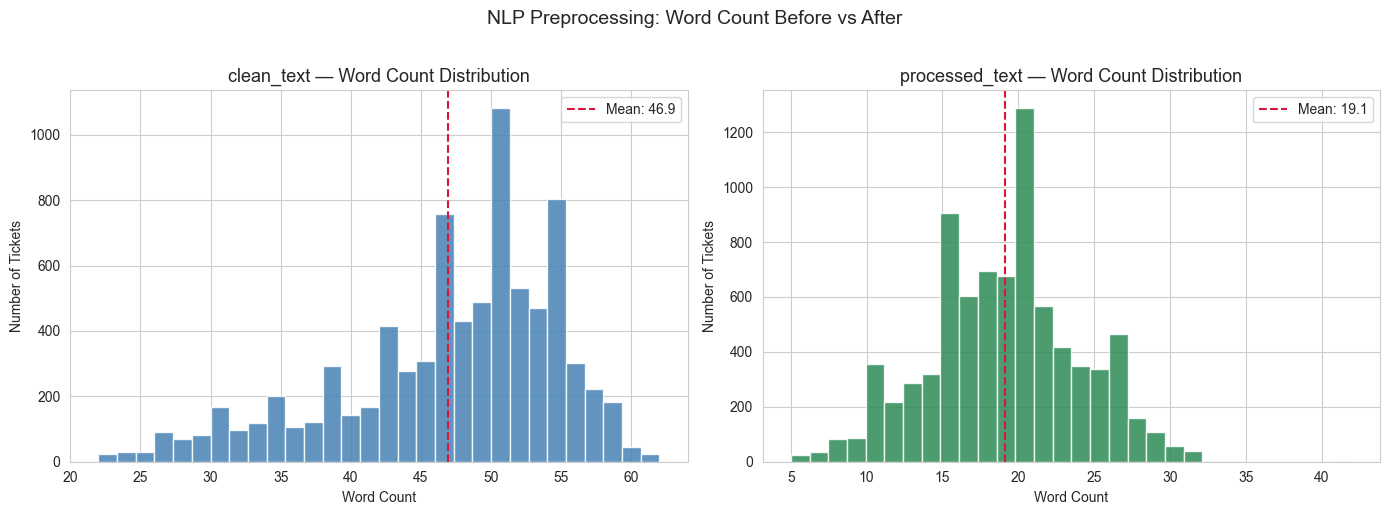

Saved: ../reports/figures/word_count_before_after.png


In [11]:
print("=== STEP 6: WORD COUNT HISTOGRAM ===\n")

wc_before = df['clean_text'].apply(lambda x: len(x.split()))
wc_after  = df['processed_text'].apply(
    lambda x: len(x.split()) if isinstance(x, str) and x.strip() else 0
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(wc_before, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('clean_text — Word Count Distribution', fontsize=13)
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Number of Tickets')
axes[0].axvline(wc_before.mean(), color='crimson', linestyle='--',
                label=f'Mean: {wc_before.mean():.1f}')
axes[0].legend()

axes[1].hist(wc_after, bins=30, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('processed_text — Word Count Distribution', fontsize=13)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Number of Tickets')
axes[1].axvline(wc_after.mean(), color='crimson', linestyle='--',
                label=f'Mean: {wc_after.mean():.1f}')
axes[1].legend()

plt.suptitle('NLP Preprocessing: Word Count Before vs After', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}word_count_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}word_count_before_after.png")

## Step 7 — Save Output CSV

In [12]:
print("=== STEP 7: SAVE OUTPUT ===\n")

# Columns saved and why:
#   processed_text  — TF-IDF input (nb 05)
#   tokens_str      — Word2Vec input (nb 06), restore with ast.literal_eval
#   task_type       — classification label, canonical name for all downstream notebooks
#   priority        — priority label, canonical name for all downstream notebooks
#   status          — needed for Week 3 workload balancing
#   clean_text      — human-readable for error analysis on misclassified examples
#
# Not saved: title, description, full_text — superseded by clean_text and processed_text
save_cols = ['processed_text', 'tokens_str', 'task_type', 'priority', 'status', 'clean_text']
df_out = df[save_cols].copy()

df_out.to_csv(OUTPUT_PATH, index=False)

size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)
print(f"Saved  : {OUTPUT_PATH}")
print(f"Shape  : {df_out.shape}")
print(f"Size   : {size_mb:.2f} MB")
print(f"\nColumns saved: {df_out.columns.tolist()}")
print(f"\nSample row:")
print(df_out.iloc[0].to_string())

=== STEP 7: SAVE OUTPUT ===

Saved  : ../data/processed/preprocessed_tasks.csv
Shape  : (8077, 6)
Size   : 4.84 MB

Columns saved: ['processed_text', 'tokens_str', 'task_type', 'priority', 'status', 'clean_text']

Sample row:
processed_text    product setup website address ive try troubles...
tokens_str        ['product', 'setup', 'website', 'address', 'iv...
task_type                                           technical issue
priority                                                   critical
status                                    Pending Customer Response
clean_text        product setup im having an issue with the plea...


## Summary

| Step | Action | Metric printed |
|---|---|---|
| 1 — Tokenization | `word_tokenize` per ticket | Avg token count |
| 2 — Stopword removal | NLTK standard + 21 domain words | Avg count before/after |
| 3 — Lemmatization | `WordNetLemmatizer` + POS tags | Vocab size before/after |
| 4 — Output formats | `processed_text` string + `tokens_str` list | Round-trip check |
| 5 — Diagnostics | Top 30 token frequencies in processed corpus | Full frequency table |
| 6 — Histogram | Word count distribution before vs after | Figure saved |
| 7 — Save | `preprocessed_tasks.csv` | Shape + size |

### What goes where

- **Notebook 05 (TF-IDF):** `TfidfVectorizer.fit_transform(df['processed_text'])`
- **Notebook 06 (Word2Vec):** `sentences = df['tokens_str'].apply(ast.literal_eval).tolist()`

### Column name contract

`task_type` and `priority` are the canonical label column names from this notebook forward. All downstream notebooks must use these exact names — inconsistent naming (`Ticket Type` vs `task_type` vs `ticket_type`) is the most common source of bugs in multi-notebook projects.